In [2]:
!pip install ultralytics opencv-python matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.1 MB/s eta 0:00:00


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files
from google.colab.patches import cv2_imshow

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
uploaded = files.upload()

video_path = list(uploaded.keys())[0]

print("Video Uploaded:", video_path)

Saving kapalbhati.mp4 to kapalbhati.mp4
Video Uploaded: kapalbhati.mp4


In [5]:
model = YOLO("yolov8n-pose.pt")

print("YOLO Pose Model Loaded Successfully")

YOLO Pose Model Loaded Successfully


In [6]:
cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = total_frames / fps

print("FPS :", fps)
print("Frames :", total_frames)
print("Duration :", round(duration,2), "sec")

FPS : 15.0
Frames : 761
Duration : 50.73 sec



0: 640x640 1 person, 465.2ms
Speed: 23.3ms preprocess, 465.2ms inference, 49.2ms postprocess per image at shape (1, 3, 640, 640)


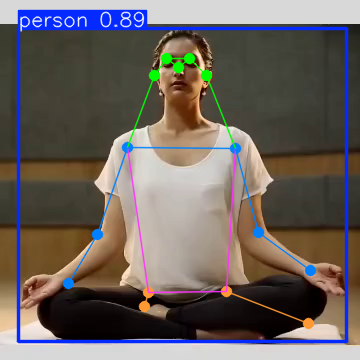

In [7]:
ret, frame = cap.read()

results = model(frame)

annotated = results[0].plot()

cv2_imshow(annotated)

cap.release()

In [8]:
ret, frame = cap.read()

results = model(frame)

if len(results[0].keypoints.xy) > 0:

    keypoints = results[0].keypoints.xy[0].cpu().numpy()

    print("Total Keypoints :", len(keypoints))

    for i, point in enumerate(keypoints):
        print(i, point)

WARNING ⚠️ 'source' is missing. Using 'source=/usr/local/lib/python3.12/dist-packages/ultralytics/assets'.

image 1/2 /usr/local/lib/python3.12/dist-packages/ultralytics/assets/bus.jpg: 640x480 4 persons, 614.0ms
image 2/2 /usr/local/lib/python3.12/dist-packages/ultralytics/assets/zidane.jpg: 384x640 2 persons, 400.1ms
Speed: 12.4ms preprocess, 507.0ms inference, 3.2ms postprocess per image at shape (1, 3, 384, 640)
Total Keypoints : 17
0 [     143.75      443.51]
1 [     149.06      435.15]
2 [     133.69      434.69]
3 [     151.99       440.7]
4 [     107.29      438.99]
5 [     163.19      494.33]
6 [     88.729      496.41]
7 [     191.32      561.59]
8 [     115.68      572.14]
9 [     157.38      537.59]
10 [     149.47       565.3]
11 [     156.17      641.19]
12 [     98.203      642.76]
13 [     182.17      750.77]
14 [     90.463       759.1]
15 [      189.3      852.22]
16 [     72.585      866.97]


In [10]:
NOSE = 0

LEFT_SHOULDER = 5
RIGHT_SHOULDER = 6

LEFT_ELBOW = 7
RIGHT_ELBOW = 8

LEFT_WRIST = 9
RIGHT_WRIST = 10

LEFT_HIP = 11
RIGHT_HIP = 12

In [11]:
left = keypoints[5]

right = keypoints[6]

difference = abs(left[1]-right[1])

print("Shoulder Difference :", difference)

if difference < 15:
    print("Balanced Shoulders")
else:
    print("Shoulders Tilted")

Shoulder Difference : 2.084137
Balanced Shoulders


In [12]:
nose = keypoints[0]

left = keypoints[5]

right = keypoints[6]

center_x = (left[0]+right[0])/2

head_shift = abs(nose[0]-center_x)

print("Head Shift :", head_shift)

if head_shift < 20:
    print("Head Position Correct")
else:
    print("Head Tilt Detected")

Head Shift : 17.794952
Head Position Correct


In [13]:
shoulder_center = (
    (keypoints[5][0]+keypoints[6][0])/2,
    (keypoints[5][1]+keypoints[6][1])/2
)

hip_center = (
    (keypoints[11][0]+keypoints[12][0])/2,
    (keypoints[11][1]+keypoints[12][1])/2
)

dx = shoulder_center[0]-hip_center[0]

print("Spine Offset :", abs(dx))

if abs(dx) < 20:
    print("Straight Spine")
else:
    print("Body Leaning")

Spine Offset : 1.2259216
Straight Spine


In [14]:
positions = []

In [15]:
center = (
    (keypoints[5][0]+keypoints[6][0])/2,
    (keypoints[5][1]+keypoints[6][1])/2
)

positions.append(center)

In [16]:
positions = np.array(positions)

movement = np.std(positions[:,0])

print("Movement :", movement)

if movement < 8:
    print("Very Stable Sitting")
elif movement < 20:
    print("Stable Sitting")
else:
    print("Body Moving Too Much")

Movement : 0.0
Very Stable Sitting


In [17]:
import math

shoulder_center = (
    (keypoints[5][0] + keypoints[6][0]) / 2,
    (keypoints[5][1] + keypoints[6][1]) / 2
)

hip_center = (
    (keypoints[11][0] + keypoints[12][0]) / 2,
    (keypoints[11][1] + keypoints[12][1]) / 2
)

chest_distance = math.sqrt(
    (shoulder_center[0]-hip_center[0])**2 +
    (shoulder_center[1]-hip_center[1])**2
)

print("Chest Distance :", round(chest_distance,2))

Chest Distance : 146.61


In [18]:
chest_history = []

In [19]:
chest_history.append(chest_distance)

In [20]:
chest_history = np.array(chest_history)

rhythm_std = np.std(chest_history)

print("Rhythm Variation :", round(rhythm_std,2))

if rhythm_std < 5:
    rhythm = "Excellent"

elif rhythm_std < 10:
    rhythm = "Good"

else:
    rhythm = "Poor"

print("Rhythm :", rhythm)

Rhythm Variation : 0.0
Rhythm : Excellent


In [21]:
score = 100

if difference > 15:
    score -= 15

if head_shift > 20:
    score -= 15

if abs(dx) > 20:
    score -= 20

if movement > 20:
    score -= 20

if rhythm_std > 10:
    score -= 30

score = max(score,0)

print("Overall Score :", score)

Overall Score : 100


In [22]:
if score >= 90:
    level = "Excellent"

elif score >= 75:
    level = "Good"

elif score >= 60:
    level = "Average"

else:
    level = "Needs Improvement"

print("Performance :", level)

Performance : Excellent


In [23]:
if score >= 90:
    level = "Excellent"

elif score >= 75:
    level = "Good"

elif score >= 60:
    level = "Average"

else:
    level = "Needs Improvement"

print("Performance :", level)

Performance : Excellent


In [24]:
print("="*50)
print("      QUALITATIVE ANALYSIS REPORT")
print("="*50)

print("Posture            :", "Correct" if abs(dx)<20 else "Incorrect")
print("Head Position      :", "Correct" if head_shift<20 else "Tilted")
print("Shoulder Alignment :", "Balanced" if difference<15 else "Unbalanced")
print("Sitting Stability  :", "Stable" if movement<20 else "Unstable")
print("Breathing Rhythm   :", rhythm)
print("Overall Score      :", score,"/100")
print("Performance        :", level)

print("="*50)

      QUALITATIVE ANALYSIS REPORT
Posture            : Correct
Head Position      : Correct
Shoulder Alignment : Balanced
Sitting Stability  : Stable
Breathing Rhythm   : Excellent
Overall Score      : 100 /100
Performance        : Excellent


In [28]:
import cv2
import numpy as np
import math
from ultralytics import YOLO

# Load Model
model = YOLO("yolov8n-pose.pt")

cap = cv2.VideoCapture(video_path)

# Lists
spine_list = []
head_list = []
shoulder_list = []
chest_list = []
movement_list = []

previous_center = None

while True:

    ret, frame = cap.read()

    if not ret:
        break

    results = model(frame, verbose=False)

    if len(results[0].keypoints.xy) == 0:
        continue

    keypoints = results[0].keypoints.xy[0].cpu().numpy()

    # Keypoints
    nose = keypoints[0]

    left_shoulder = keypoints[5]
    right_shoulder = keypoints[6]

    left_hip = keypoints[11]
    right_hip = keypoints[12]

    # Shoulder Alignment
    shoulder_difference = abs(left_shoulder[1] - right_shoulder[1])
    shoulder_list.append(shoulder_difference)

    # Shoulder Center
    shoulder_center = (
        (left_shoulder[0] + right_shoulder[0]) / 2,
        (left_shoulder[1] + right_shoulder[1]) / 2
    )

    # Hip Center
    hip_center = (
        (left_hip[0] + right_hip[0]) / 2,
        (left_hip[1] + right_hip[1]) / 2
    )

    # Head Position
    head_shift = abs(nose[0] - shoulder_center[0])
    head_list.append(head_shift)

    # Spine Alignment
    spine_offset = abs(shoulder_center[0] - hip_center[0])
    spine_list.append(spine_offset)

    # Chest Distance
    chest_distance = math.sqrt(
        (shoulder_center[0] - hip_center[0])**2 +
        (shoulder_center[1] - hip_center[1])**2
    )
    chest_list.append(chest_distance)

    # Body Movement
    if previous_center is not None:
        movement = math.sqrt(
            (shoulder_center[0] - previous_center[0])**2 +
            (shoulder_center[1] - previous_center[1])**2
        )
        movement_list.append(movement)

    previous_center = shoulder_center

cap.release()

print("Video Analysis Completed")

Video Analysis Completed


In [29]:
import numpy as np

avg_spine = np.mean(spine_list) if spine_list else 0
avg_head = np.mean(head_list) if head_list else 0
avg_shoulder = np.mean(shoulder_list) if shoulder_list else 0
avg_chest = np.mean(chest_list) if chest_list else 0
avg_movement = np.mean(movement_list) if movement_list else 0

rhythm_std = np.std(chest_list) if chest_list else 0

print("Average Spine Offset :", round(avg_spine,2))
print("Average Head Shift :", round(avg_head,2))
print("Average Shoulder Difference :", round(avg_shoulder,2))
print("Average Chest Distance :", round(avg_chest,2))
print("Average Body Movement :", round(avg_movement,2))
print("Rhythm STD :", round(rhythm_std,2))

Average Spine Offset : 4.58
Average Head Shift : 5.85
Average Shoulder Difference : 1.58
Average Chest Distance : 144.31
Average Body Movement : 0.4
Rhythm STD : 2.36


In [30]:
score = 100

if avg_spine > 20:
    score -= 20

if avg_head > 20:
    score -= 15

if avg_shoulder > 15:
    score -= 15

if avg_movement > 15:
    score -= 20

if rhythm_std > 10:
    score -= 30

score = max(score, 0)

print("Overall Score :", score)

Overall Score : 100


In [31]:
if score >= 90:
    performance = "Excellent"
elif score >= 75:
    performance = "Good"
elif score >= 60:
    performance = "Average"
else:
    performance = "Needs Improvement"

print("Performance :", performance)

Performance : Excellent


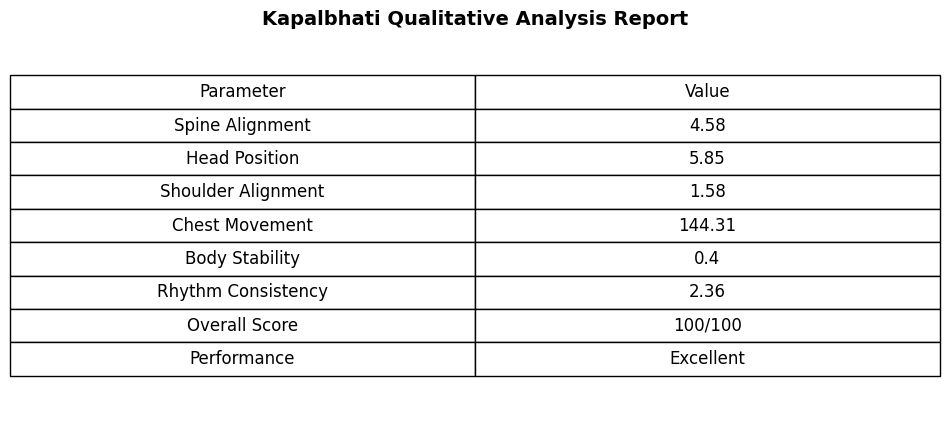

In [33]:
import matplotlib.pyplot as plt

parameters = [
    "Spine Alignment",
    "Head Position",
    "Shoulder Alignment",
    "Chest Movement",
    "Body Stability",
    "Rhythm Consistency",
    "Overall Score",
    "Performance"
]

values = [
    round(avg_spine,2),
    round(avg_head,2),
    round(avg_shoulder,2),
    round(avg_chest,2),
    round(avg_movement,2),
    round(rhythm_std,2),
    f"{score}/100",
    performance
]

fig, ax = plt.subplots(figsize=(10,5))
ax.axis('off')

table = ax.table(
    cellText=[[p, v] for p, v in zip(parameters, values)],
    colLabels=["Parameter", "Value"],
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2)

plt.title("Kapalbhati Qualitative Analysis Report", fontsize=14, fontweight="bold")

plt.savefig("qualitative_results.png", dpi=300, bbox_inches="tight")
plt.show()

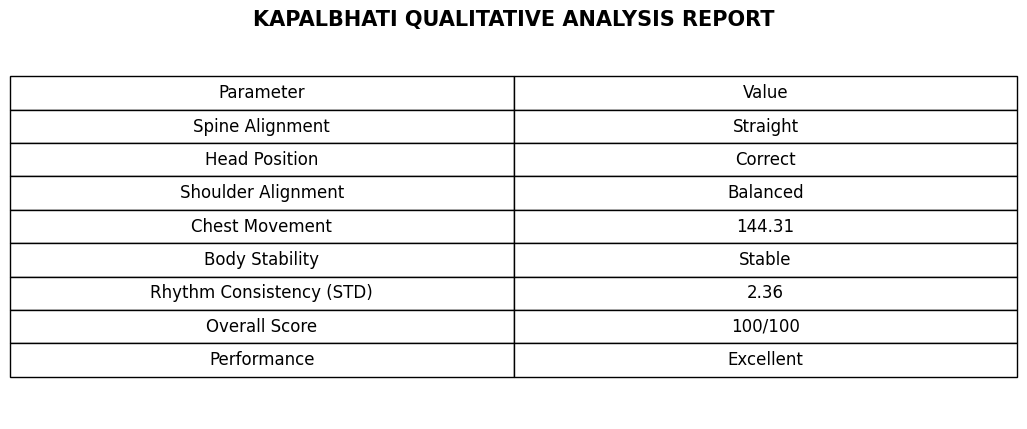

In [35]:
import matplotlib.pyplot as plt

# -------------------------------
# Qualitative Parameters
# -------------------------------

parameters = [
    "Spine Alignment",
    "Head Position",
    "Shoulder Alignment",
    "Chest Movement",
    "Body Stability",
    "Rhythm Consistency (STD)",
    "Overall Score",
    "Performance"
]

values = [

    "Straight" if avg_spine < 20 else "Leaning",

    "Correct" if avg_head < 20 else "Tilted",

    "Balanced" if avg_shoulder < 15 else "Unbalanced",

    round(avg_chest,2),

    "Stable" if avg_movement < 15 else "Unstable",

    round(rhythm_std,2),

    f"{score}/100",

    performance

]

# -------------------------------
# Create Table
# -------------------------------

fig, ax = plt.subplots(figsize=(10,5))

ax.axis('off')

table = ax.table(

    cellText=[[p,v] for p,v in zip(parameters,values)],

    colLabels=["Parameter","Value"],

    loc='center',

    cellLoc='center'

)

table.auto_set_font_size(False)

table.set_fontsize(12)

table.scale(1.3,2)

plt.title(
    "KAPALBHATI QUALITATIVE ANALYSIS REPORT",
    fontsize=15,
    weight='bold'
)

plt.savefig(
    "qualitative_results.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [36]:
import pandas as pd

df = pd.DataFrame({

    "Parameter":parameters,

    "Value":values

})

df.to_csv(

    "qualitative_report.csv",

    index=False

)

print("CSV Saved Successfully")

CSV Saved Successfully


In [37]:
from google.colab import files

files.download("qualitative_results.png")

files.download("qualitative_report.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>